# August 6 batch — quick trajectory review

Exploratory, quick-look figures for the 5 newest long-sequence recordings
(2026-08-06 batch), rotated-caret layouts. **None of these 5 sessions have a
formal `spatial_annotation.json`** (the `analysis/spatial_sequence` annotation
tool has not been run on them yet), so this notebook does **not** use that
calibrated pipeline. Instead it follows the same pattern already established
in `analysis/notebooks/09_long_random_sequence_shape_maps.ipynb` and
`10_long_sequence_qc_transfer_and_32d.ipynb`: a fixed paper registration
(`paper_x = 40.0 - desk_x`, `paper_y = 46.5 - desk_y`, carried forward
unchanged from notebook 09 through notebook 10's addition of the August 3
batch — both notebooks' session notes state a fixed desk tag and camera, and
the August 6 session notes reconfirm "fixed desk tag and camera" again) plus
**protocol-approximate source overlays** (not measured from a setup photo).

The August 6 source geometry is new: the recorded notes describe
**upper/lower** arms rather than notebook 09's **left/right** arms, i.e. the
same caret template rotated 90 degrees. The four new segments below are
derived from notebook 09/10's existing `caret_left`/`caret_right` coordinates
by that rotation (swap x/y, then mirror for the opposite-pointing caret) —
see the comment above `SEGMENTS`. This is a geometric derivation from the
existing protocol template, not an independent measurement, exactly like the
existing "protocol-approximate" segments already in this repo.


In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon, Patch
from IPython.display import display, Markdown

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'experiments').is_dir() and (candidate / 'record_cyranose_reading_pose.py').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the realsense-apriltag repository.')

ROOT = find_repo_root()
BATCH_DIR = ROOT / 'experiments' / 'long-sequence' / '2026-08-06_batch-01' / 'runs'
print('Repository:', ROOT)
print('Batch directory:', BATCH_DIR.relative_to(ROOT))

Repository: /Users/audreytjokro/Documents/realsense-apriltag
Batch directory: experiments/long-sequence/2026-08-06_batch-01/runs


In [2]:
# Paper registration and colors: unchanged from notebooks 09/10.
PAPER_SIZE_CM = 26.5
PAPER_X_ORIGIN = 40.0
PAPER_Y_ORIGIN = 46.5

MINT = "#82d8ad"
LAVENDER = "#c5a3e6"
EARLY = "#2ca25f"
MIDDLE = "#ffd92f"
LATE = "#d73027"

# Notebook 09/10's original July caret template (apex near the top, y=5,
# arms spreading down to y=21.5), carried forward unchanged:
#   caret_left:  (4.75, 21.5) -> (11.25, 5.0)
#   caret_right: (15.25, 5.0) -> (21.75, 21.5)
# August 6's sessions describe an "upper arm" / "lower arm" caret instead of
# left/right -- i.e. the same template rotated 90 degrees so the apex points
# sideways. Swapping (x, y) -> (y, x) on the original points rotates the
# apex from top to the left edge; mirroring x -> (PAPER_SIZE_CM - x) flips it
# to point right instead. Width kept at 3.0 cm (the July value) since the
# August 6 notes describe this as a rotated-caret sequence following the same
# template, not the August 3 batch's separate 2.0 cm X/parallel protocol.
SEGMENTS = {
    "horizontal": ((4.75, 13.25), (21.75, 13.25), 3.0),
    "caret_left": ((4.75, 21.5), (11.25, 5.0), 3.0),
    "caret_right": ((15.25, 5.0), (21.75, 21.5), 3.0),
    "inverted_left": ((4.75, 5.0), (11.25, 21.5), 3.0),
    "inverted_right": ((15.25, 21.5), (21.75, 5.0), 3.0),
    # New for August 6 (derived as described above; see the markdown cell above):
    "left_caret_upper": ((21.5, 4.75), (5.0, 11.25), 3.0),
    "left_caret_lower": ((5.0, 15.25), (21.5, 21.75), 3.0),
    "right_caret_upper": ((5.0, 4.75), (21.5, 11.25), 3.0),
    "right_caret_lower": ((21.5, 15.25), (5.0, 21.75), 3.0),
}

RUN_SPECS = [
    dict(session="cyranose_reading_pose_session_20260806_145217",
         title="Aug 06 · left caret · lavender upper / mint lower · run01",
         mint=["left_caret_lower"], lavender=["left_caret_upper"]),
    dict(session="cyranose_reading_pose_session_20260806_151752",
         title="Aug 06 · left caret · lavender upper / mint lower · run02",
         mint=["left_caret_lower"], lavender=["left_caret_upper"]),
    dict(session="cyranose_reading_pose_session_20260806_155423",
         title="Aug 06 · right caret · mint upper / lavender lower · run01",
         mint=["right_caret_upper"], lavender=["right_caret_lower"]),
    dict(session="cyranose_reading_pose_session_20260806_161632",
         title="Aug 06 · right caret · mint upper / lavender lower · run02",
         mint=["right_caret_upper"], lavender=["right_caret_lower"]),
    dict(session="cyranose_reading_pose_session_20260806_165041",
         title="Aug 06 · left caret · mint upper / lavender lower · run01",
         mint=["left_caret_upper"], lavender=["left_caret_lower"]),
]
print(f"{len(RUN_SPECS)} sessions configured")

5 sessions configured


In [3]:
def segment_polygon(segment):
    (x1, y1), (x2, y2), width = segment
    vx, vy = x2 - x1, y2 - y1
    length = math.hypot(vx, vy)
    px, py = -(vy / length) * width / 2.0, (vx / length) * width / 2.0
    return np.array([[x1 + px, y1 + py], [x2 + px, y2 + py], [x2 - px, y2 - py], [x1 - px, y1 - py]])


def draw_sources(ax, spec):
    for odor, color in [("mint", MINT), ("lavender", LAVENDER)]:
        for name in spec[odor]:
            ax.add_patch(Polygon(segment_polygon(SEGMENTS[name]), closed=True,
                                  facecolor=color, edgecolor=color, alpha=0.22, linewidth=1.5, linestyle="--"))


def load_trajectory(session_name):
    session_dir = BATCH_DIR / session_name
    frame = pd.read_csv(session_dir / "cyranose_reading_pose.csv")
    active = frame[frame["pcnose_flag"] == 2].copy()
    pose_valid = active["snout_position_valid"].astype(bool) & np.all(
        np.isfinite(active[["snout_desk_x_cm", "snout_desk_y_cm"]].to_numpy(dtype=float)), axis=1
    )
    active = active.loc[pose_valid].copy()
    active["paper_x"] = PAPER_X_ORIGIN - active["snout_desk_x_cm"].astype(float)
    active["paper_y"] = PAPER_Y_ORIGIN - active["snout_desk_y_cm"].astype(float)
    time_s = pd.to_numeric(active["pose_elapsed_s"], errors="coerce").to_numpy(float)
    active["progress"] = (time_s - time_s.min()) / max(time_s.max() - time_s.min(), 1e-9)
    on_paper = active["paper_x"].between(0, PAPER_SIZE_CM) & active["paper_y"].between(0, PAPER_SIZE_CM)
    return active, float(on_paper.mean())

trajectories = {}
qc_rows = []
for spec in RUN_SPECS:
    traj, on_paper_fraction = load_trajectory(spec["session"])
    trajectories[spec["session"]] = traj
    qc_rows.append({
        "session": spec["session"],
        "title": spec["title"],
        "flag-2 pose-valid rows": len(traj),
        "duration (min)": (traj["pose_elapsed_s"].astype(float).max() - traj["pose_elapsed_s"].astype(float).min()) / 60.0,
        "fraction landing inside [0, 26.5cm] paper bounds": on_paper_fraction,
    })
qc_table = pd.DataFrame(qc_rows)
display(qc_table.round(3))
display(Markdown(
    "**Sanity check on the carried-forward paper registration:** if `paper_x = 40.0 - desk_x` / "
    "`paper_y = 46.5 - desk_y` were wrong for this new batch (e.g. paper moved, desk tag redone), "
    "trajectories would land mostly *outside* the 0-26.5 cm square above. The fraction landing inside "
    "is the check -- close to 1.0 supports carrying the registration forward as-is."
))

,session,title,flag-2 pose-valid rows,duration (min),"fraction landing inside [0, 26.5cm] paper bounds"
0,cyranose_reading_pose_session_20260806_145217,Aug 06 · left caret · lavender upper / mint lo...,1098,10.234,0.901
1,cyranose_reading_pose_session_20260806_151752,Aug 06 · left caret · lavender upper / mint lo...,1117,10.721,0.939
2,cyranose_reading_pose_session_20260806_155423,Aug 06 · right caret · mint upper / lavender l...,1102,10.387,0.926
3,cyranose_reading_pose_session_20260806_161632,Aug 06 · right caret · mint upper / lavender l...,1049,10.424,0.960
4,cyranose_reading_pose_session_20260806_165041,Aug 06 · left caret · mint upper / lavender lo...,1113,10.561,0.939


**Sanity check on the carried-forward paper registration:** if `paper_x = 40.0 - desk_x` / `paper_y = 46.5 - desk_y` were wrong for this new batch (e.g. paper moved, desk tag redone), trajectories would land mostly *outside* the 0-26.5 cm square above. The fraction landing inside is the check -- close to 1.0 supports carrying the registration forward as-is.

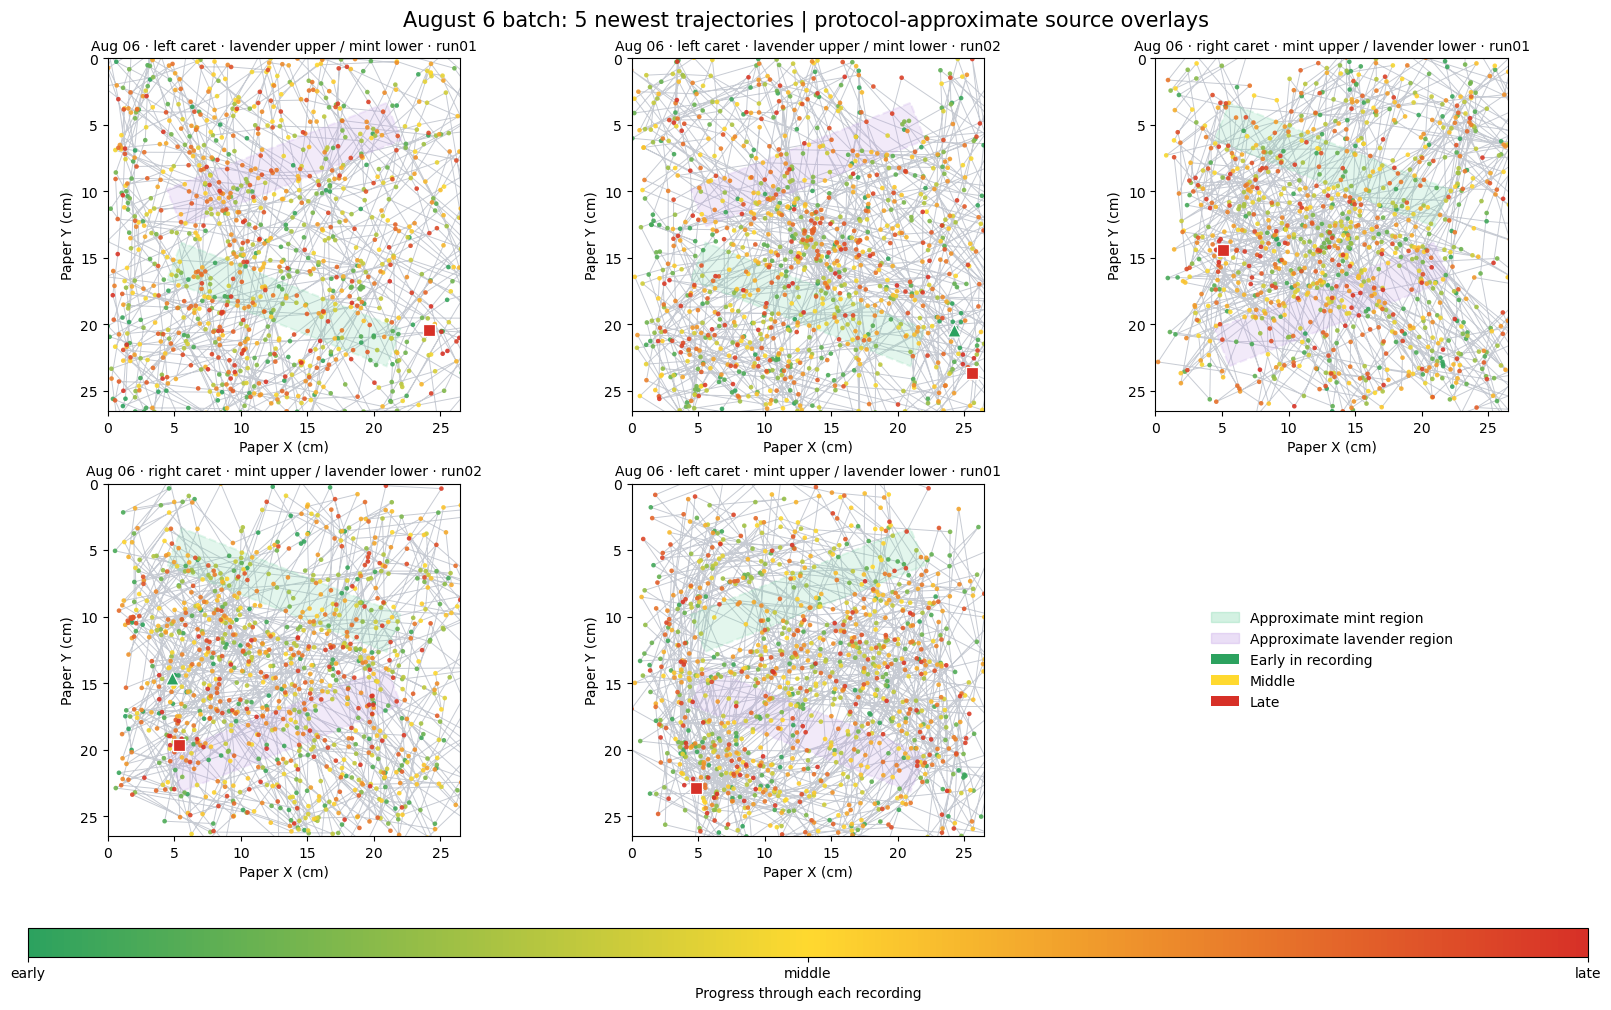

Saved: analysis/figures/august6_trajectory_overview.png


In [4]:
time_cmap = mcolors.LinearSegmentedColormap.from_list("early_middle_late", [EARLY, MIDDLE, LATE])

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
for ax, spec in zip(axes.flat, RUN_SPECS):
    traj = trajectories[spec["session"]].sort_values("pose_elapsed_s")
    ax.plot(traj["paper_x"], traj["paper_y"], color="#9098a8", linewidth=0.7, alpha=0.5, zorder=1)
    ax.scatter(traj["paper_x"], traj["paper_y"], c=traj["progress"], cmap=time_cmap,
               vmin=0, vmax=1, s=11, linewidths=0, alpha=0.9, zorder=2)
    draw_sources(ax, spec)
    ax.scatter(traj.iloc[0]["paper_x"], traj.iloc[0]["paper_y"], marker="^", s=90, color=EARLY,
               edgecolor="white", linewidth=0.9, zorder=4)
    ax.scatter(traj.iloc[-1]["paper_x"], traj.iloc[-1]["paper_y"], marker="s", s=70, color=LATE,
               edgecolor="white", linewidth=0.9, zorder=4)
    ax.set_title(spec["title"], fontsize=10)
    ax.set_xlim(0, PAPER_SIZE_CM)
    ax.set_ylim(PAPER_SIZE_CM, 0)
    ax.set_aspect("equal")
    ax.set_xlabel("Paper X (cm)")
    ax.set_ylabel("Paper Y (cm)")

axes.flat[-1].axis("off")
axes.flat[-1].legend(
    handles=[
        Patch(facecolor=MINT, edgecolor=MINT, alpha=0.35, label="Approximate mint region"),
        Patch(facecolor=LAVENDER, edgecolor=LAVENDER, alpha=0.35, label="Approximate lavender region"),
        Patch(facecolor=EARLY, label="Early in recording"),
        Patch(facecolor=MIDDLE, label="Middle"),
        Patch(facecolor=LATE, label="Late"),
    ],
    loc="center", frameon=False, fontsize=10,
)
sm = plt.cm.ScalarMappable(norm=mcolors.Normalize(0, 1), cmap=time_cmap)
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.045, pad=0.06, aspect=55)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["early", "middle", "late"])
cbar.set_label("Progress through each recording")
fig.suptitle("August 6 batch: 5 newest trajectories | protocol-approximate source overlays", fontsize=15)

output_path = ROOT / "analysis" / "figures" / "august6_trajectory_overview.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", output_path.relative_to(ROOT))

## Caveats

- **No formal annotation exists for these 5 sessions.** The source overlays above are a
  geometric derivation from the existing protocol-approximate template used in notebooks 09/10,
  not independently measured or clicked against video for this batch specifically.
- **Paper registration is carried forward, not re-verified**, from notebook 09 (July 30) and
  notebook 10 (August 3) — supported by the "fraction landing inside paper bounds" sanity check
  above and by the session notes' "fixed desk tag and camera," but not confirmed the way a real
  annotation pass would confirm it.
- **No lag correction, no height filtering, no synchronization QC applied here** -- this is a raw
  pose-trajectory view only, meant for a quick look, not for scoring or modeling.
